# NB02: Phenotype Feature Engineering

Build a species-level phenotype feature matrix from BacDive data.

**Value encoding rules**:
- Metabolite utilization: `+` → positive, `-` → negative, `produced` → positive, `+/-` → exclude
- Enzyme activity: `+` → positive, `-` → negative, `+/-` → exclude
- Physiology: measured values only (not AI-predicted)

**Species-level aggregation**:
- Categorical: majority vote + agreement score
- Binary: fraction positive, binarize at 0.5
- Continuous: mean across strains

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

MAIN_REPO = '/home/psdehal/pangenome_science/BERIL-research-observatory'
PROJ = os.path.join(MAIN_REPO, 'projects', 'bacdive_phenotype_metal_tolerance')
BACDIVE = os.path.join(MAIN_REPO, 'data', 'bacdive_ingest')
DATA_OUT = os.path.join(PROJ, 'data')
FIG_OUT = os.path.join(PROJ, 'figures')

# Load bridge from NB01
matched = pd.read_csv(os.path.join(DATA_OUT, 'matched_strains.csv'))
matched_ids = set(matched['bacdive_id'])
print(f'Matched strains: {len(matched):,}, species: {matched["gtdb_species_clade_id"].nunique():,}')

# Load BacDive tables
phys = pd.read_csv(os.path.join(BACDIVE, 'physiology.tsv'), sep='\t')
mu = pd.read_csv(os.path.join(BACDIVE, 'metabolite_utilization.tsv'), sep='\t')
enz = pd.read_csv(os.path.join(BACDIVE, 'enzyme.tsv'), sep='\t')
iso = pd.read_csv(os.path.join(BACDIVE, 'isolation.tsv'), sep='\t')

Matched strains: 37,368, species: 5,647


## 1. Extract strain-level phenotype features

In [2]:
# Filter to matched strains only
m_phys = phys[phys['bacdive_id'].isin(matched_ids)].copy()
m_mu = mu[mu['bacdive_id'].isin(matched_ids)].copy()
m_enz = enz[enz['bacdive_id'].isin(matched_ids)].copy()
m_iso = iso[iso['bacdive_id'].isin(matched_ids)].copy()

print(f'Matched physiology: {len(m_phys)}')
print(f'Matched metabolite util: {len(m_mu)}')
print(f'Matched enzyme: {len(m_enz)}')
print(f'Matched isolation: {len(m_iso)}')

Matched physiology: 37368
Matched metabolite util: 519982
Matched enzyme: 363657
Matched isolation: 29768


In [3]:
# --- Physiology features (measured only) ---
# Gram stain: binary (exclude 'variable')
gram = m_phys[m_phys['gram_stain'].isin(['positive', 'negative'])][['bacdive_id', 'gram_stain']].copy()
gram['gram_positive'] = (gram['gram_stain'] == 'positive').astype(int)

# Oxygen tolerance: keep top categories
oxy = m_phys[m_phys['oxygen_tolerance'].notna()][['bacdive_id', 'oxygen_tolerance']].copy()
# Simplify to 3 categories: aerobe, anaerobe, facultative
oxy_map = {
    'aerobe': 'aerobe', 'obligate aerobe': 'aerobe', 'facultative aerobe': 'aerobe',
    'anaerobe': 'anaerobe', 'obligate anaerobe': 'anaerobe',
    'facultative anaerobe': 'facultative',
    'microaerophile': 'facultative', 'microaerotolerant': 'facultative',
    'aerotolerant': 'facultative',
}
oxy['oxygen_simple'] = oxy['oxygen_tolerance'].map(oxy_map)
oxy = oxy[oxy['oxygen_simple'].notna()]

# Motility: binary
mot = m_phys[m_phys['motility'].isin(['yes', 'no'])][['bacdive_id', 'motility']].copy()
mot['motile'] = (mot['motility'] == 'yes').astype(int)

print(f'Gram stain: {len(gram)} strains')
print(f'Oxygen: {len(oxy)} strains')
print(f'Motility: {len(mot)} strains')

Gram stain: 7411 strains
Oxygen: 11708 strains
Motility: 6474 strains


In [4]:
# --- Enzyme features (explicit +/- only) ---
def extract_enzyme(enzyme_name_pattern, col_name):
    """Extract binary enzyme activity for matched strains."""
    mask = (m_enz['enzyme_name'].str.contains(enzyme_name_pattern, case=False, na=False) &
            m_enz['activity'].isin(['+', '-']))
    df = m_enz[mask][['bacdive_id', 'activity']].copy()
    df[col_name] = (df['activity'] == '+').astype(int)
    # If a strain has multiple tests, take majority
    df = df.groupby('bacdive_id')[col_name].agg(lambda x: int(x.mean() >= 0.5)).reset_index()
    return df

catalase = extract_enzyme('^catalase$', 'catalase_pos')
# Oxidase: exclude cytochrome oxidase (different test)
oxidase_mask = (m_enz['enzyme_name'].str.contains('oxidase', case=False, na=False) &
                ~m_enz['enzyme_name'].str.contains('cytochrome|peroxidase', case=False, na=False) &
                m_enz['activity'].isin(['+', '-']))
oxidase_df = m_enz[oxidase_mask][['bacdive_id', 'activity']].copy()
oxidase_df['oxidase_pos'] = (oxidase_df['activity'] == '+').astype(int)
oxidase = oxidase_df.groupby('bacdive_id')['oxidase_pos'].agg(lambda x: int(x.mean() >= 0.5)).reset_index()

urease = extract_enzyme('^urease$', 'urease_pos')

print(f'Catalase: {len(catalase)} strains')
print(f'Oxidase: {len(oxidase)} strains')
print(f'Urease: {len(urease)} strains')

Catalase: 7876 strains
Oxidase: 5014 strains
Urease: 14343 strains


In [5]:
# --- Metabolite features (explicit +/- only, exclude +/-) ---
def extract_metabolite(compound_name, col_name, include_produced=False):
    """Extract binary metabolite utilization for matched strains."""
    valid_pos = ['+'] + (['produced'] if include_produced else [])
    valid_vals = valid_pos + ['-']
    mask = (m_mu['compound_name'] == compound_name) & (m_mu['utilization'].isin(valid_vals))
    df = m_mu[mask][['bacdive_id', 'utilization']].copy()
    df[col_name] = df['utilization'].isin(valid_pos).astype(int)
    df = df.groupby('bacdive_id')[col_name].agg(lambda x: int(x.mean() >= 0.5)).reset_index()
    return df

nitrate = extract_metabolite('nitrate', 'nitrate_pos')
h2s = extract_metabolite('hydrogen sulfide', 'h2s_pos', include_produced=True)
acetate = extract_metabolite('acetate', 'acetate_pos')

print(f'Nitrate reduction: {len(nitrate)} strains')
print(f'H₂S production: {len(h2s)} strains')
print(f'Acetate utilization: {len(acetate)} strains')

Nitrate reduction: 11357 strains
H₂S production: 2611 strains
Acetate utilization: 475 strains


In [6]:
# --- Breadth features ---
# Metabolite breadth: count of explicit '+' results per strain
met_pos = m_mu[m_mu['utilization'] == '+'].groupby('bacdive_id').size().reset_index(name='metabolite_breadth')
met_total = m_mu[m_mu['utilization'].isin(['+', '-'])].groupby('bacdive_id').size().reset_index(name='metabolite_tests')
met_breadth = met_pos.merge(met_total, on='bacdive_id', how='outer').fillna(0)
met_breadth['metabolite_frac_pos'] = met_breadth['metabolite_breadth'] / met_breadth['metabolite_tests'].clip(lower=1)

# Enzyme breadth: count of explicit '+' results per strain
enz_pos = m_enz[m_enz['activity'] == '+'].groupby('bacdive_id').size().reset_index(name='enzyme_breadth')
enz_total = m_enz[m_enz['activity'].isin(['+', '-'])].groupby('bacdive_id').size().reset_index(name='enzyme_tests')
enz_breadth = enz_pos.merge(enz_total, on='bacdive_id', how='outer').fillna(0)
enz_breadth['enzyme_frac_pos'] = enz_breadth['enzyme_breadth'] / enz_breadth['enzyme_tests'].clip(lower=1)

print(f'Metabolite breadth: {len(met_breadth)} strains')
print(f'Enzyme breadth: {len(enz_breadth)} strains')

Metabolite breadth: 16454 strains
Enzyme breadth: 16005 strains


In [7]:
# --- Isolation source ---
iso_feat = m_iso[m_iso['cat1'].notna()][['bacdive_id', 'cat1']].copy()
# Simplify to 3 categories
iso_map = {
    '#Host': 'host', '#Host Body-Site': 'host', '#Host Body Product': 'host',
    '#Infection': 'host',
    '#Environmental': 'environmental',
    '#Engineered': 'engineered',
    '#Condition': 'other', '#Climate': 'other',
}
iso_feat['isolation_category'] = iso_feat['cat1'].map(iso_map)
iso_feat = iso_feat[iso_feat['isolation_category'].notna()]
print(f'Isolation source: {len(iso_feat)} strains')
print(iso_feat['isolation_category'].value_counts().to_string())

Isolation source: 22581 strains
isolation_category
host             12312
environmental     7039
engineered        3146
other               84


## 2. Aggregate to species level

In [8]:
# Map bacdive_id → species
id_to_species = matched.set_index('bacdive_id')['gtdb_species_clade_id'].to_dict()

def aggregate_binary(df, value_col, species_map):
    """Aggregate binary feature to species level with agreement score."""
    df = df.copy()
    df['species'] = df['bacdive_id'].map(species_map)
    df = df[df['species'].notna()]
    agg = df.groupby('species')[value_col].agg(['mean', 'count']).reset_index()
    agg.columns = ['species', f'{value_col}_frac', f'{value_col}_n_strains']
    agg[f'{value_col}_binary'] = (agg[f'{value_col}_frac'] >= 0.5).astype(int)
    agg[f'{value_col}_agreement'] = agg[f'{value_col}_frac'].apply(
        lambda x: max(x, 1 - x)  # agreement = fraction of majority call
    )
    return agg

def aggregate_categorical(df, value_col, species_map):
    """Aggregate categorical feature to species level with majority vote."""
    df = df.copy()
    df['species'] = df['bacdive_id'].map(species_map)
    df = df[df['species'].notna()]
    
    # Majority vote
    majority = df.groupby('species')[value_col].agg(
        lambda x: x.value_counts().index[0]
    ).reset_index()
    majority.columns = ['species', f'{value_col}_majority']
    
    # Agreement score
    agreement = df.groupby('species')[value_col].agg(
        lambda x: x.value_counts().iloc[0] / len(x)
    ).reset_index()
    agreement.columns = ['species', f'{value_col}_agreement']
    
    return majority.merge(agreement, on='species')

def aggregate_continuous(df, value_col, species_map):
    """Aggregate continuous feature to species level."""
    df = df.copy()
    df['species'] = df['bacdive_id'].map(species_map)
    df = df[df['species'].notna()]
    agg = df.groupby('species')[value_col].agg(['mean', 'std', 'count']).reset_index()
    agg.columns = ['species', f'{value_col}_mean', f'{value_col}_std', f'{value_col}_n_strains']
    return agg

# Aggregate all features
sp_gram = aggregate_binary(gram, 'gram_positive', id_to_species)
sp_motile = aggregate_binary(mot, 'motile', id_to_species)
sp_catalase = aggregate_binary(catalase, 'catalase_pos', id_to_species)
sp_oxidase = aggregate_binary(oxidase, 'oxidase_pos', id_to_species)
sp_urease = aggregate_binary(urease, 'urease_pos', id_to_species)
sp_nitrate = aggregate_binary(nitrate, 'nitrate_pos', id_to_species)
sp_h2s = aggregate_binary(h2s, 'h2s_pos', id_to_species)
sp_acetate = aggregate_binary(acetate, 'acetate_pos', id_to_species)

sp_oxygen = aggregate_categorical(oxy, 'oxygen_simple', id_to_species)

sp_met_breadth = aggregate_continuous(met_breadth, 'metabolite_frac_pos', id_to_species)
sp_enz_breadth = aggregate_continuous(enz_breadth, 'enzyme_frac_pos', id_to_species)

print('Species-level feature counts:')
for name, df in [('Gram', sp_gram), ('Oxygen', sp_oxygen), ('Motility', sp_motile),
                 ('Catalase', sp_catalase), ('Oxidase', sp_oxidase), ('Urease', sp_urease),
                 ('Nitrate', sp_nitrate), ('H₂S', sp_h2s), ('Acetate', sp_acetate),
                 ('Met breadth', sp_met_breadth), ('Enz breadth', sp_enz_breadth)]:
    print(f'  {name:15s}: {len(df)} species')

Species-level feature counts:
  Gram           : 3272 species
  Oxygen         : 3751 species
  Motility       : 3138 species
  Catalase       : 2930 species
  Oxidase        : 1799 species
  Urease         : 3035 species
  Nitrate        : 3088 species
  H₂S            : 880 species
  Acetate        : 422 species
  Met breadth    : 3930 species
  Enz breadth    : 3746 species


## 3. Merge into species-level feature matrix

In [9]:
# Start with all matched species and their metal scores
species_scores = matched[['gtdb_species_clade_id', 'metal_score_norm', 'metal_score_raw', 
                          'n_metal_clusters', 'no_genomes', 'bacdive_phylum', 'bacdive_class',
                          'bacdive_order']].drop_duplicates(subset='gtdb_species_clade_id')
species_scores = species_scores.rename(columns={'gtdb_species_clade_id': 'species'})

print(f'Starting species: {len(species_scores)}')

# Merge all features
feat_matrix = species_scores.copy()

# Binary features — merge fraction and binary call
for name, df, col in [
    ('gram', sp_gram, 'gram_positive'),
    ('motile', sp_motile, 'motile'),
    ('catalase', sp_catalase, 'catalase_pos'),
    ('oxidase', sp_oxidase, 'oxidase_pos'),
    ('urease', sp_urease, 'urease_pos'),
    ('nitrate', sp_nitrate, 'nitrate_pos'),
    ('h2s', sp_h2s, 'h2s_pos'),
    ('acetate', sp_acetate, 'acetate_pos'),
]:
    merge_cols = ['species', f'{col}_binary', f'{col}_frac', f'{col}_agreement']
    feat_matrix = feat_matrix.merge(df[merge_cols], on='species', how='left')

# Oxygen: merge majority call
if 'oxygen_simple_majority' in sp_oxygen.columns:
    feat_matrix = feat_matrix.merge(
        sp_oxygen[['species', 'oxygen_simple_majority', 'oxygen_simple_agreement']], 
        on='species', how='left'
    )

# Continuous features
feat_matrix = feat_matrix.merge(
    sp_met_breadth[['species', 'metabolite_frac_pos_mean']], on='species', how='left'
)
feat_matrix = feat_matrix.merge(
    sp_enz_breadth[['species', 'enzyme_frac_pos_mean']], on='species', how='left'
)

print(f'\nFinal feature matrix: {len(feat_matrix)} species × {len(feat_matrix.columns)} columns')

# Count non-null features per species
feature_cols = [c for c in feat_matrix.columns if c.endswith('_binary') or c.endswith('_majority') 
                or c.endswith('_mean')]
feat_matrix['n_features'] = feat_matrix[feature_cols].notna().sum(axis=1)
print(f'\nFeature completeness distribution:')
print(feat_matrix['n_features'].describe().to_string())
print(f'\nSpecies with ≥5 features: {(feat_matrix["n_features"] >= 5).sum()}')
print(f'Species with ≥8 features: {(feat_matrix["n_features"] >= 8).sum()}')
print(f'Species with all {len(feature_cols)} features: {(feat_matrix["n_features"] == len(feature_cols)).sum()}')

Starting species: 5647

Final feature matrix: 5647 species × 36 columns

Feature completeness distribution:
count    5647.000000
mean        5.310962
std         3.677967
min         0.000000
25%         1.000000
50%         6.000000
75%         9.000000
max        11.000000

Species with ≥5 features: 3437
Species with ≥8 features: 2318
Species with all 11 features: 37


Saved: data/species_phenotype_matrix.csv (5647 species)


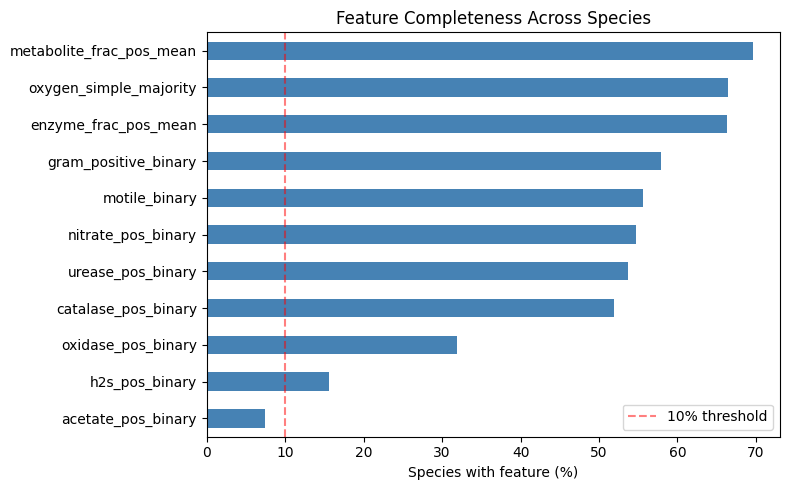

Saved: figures/feature_completeness.png


In [10]:
# Save feature matrix
feat_matrix.to_csv(os.path.join(DATA_OUT, 'species_phenotype_matrix.csv'), index=False)
print(f'Saved: data/species_phenotype_matrix.csv ({len(feat_matrix)} species)')

# Summary visualization: feature completeness heatmap
fig, ax = plt.subplots(figsize=(8, 5))
completeness = feat_matrix[feature_cols].notna().sum() / len(feat_matrix) * 100
completeness.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Species with feature (%)')
ax.set_title('Feature Completeness Across Species')
ax.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='10% threshold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_OUT, 'feature_completeness.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/feature_completeness.png')